<a href="https://colab.research.google.com/github/tushtk9/Housing/blob/main/Hotel_Booking_Analysis_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## <b> Have you ever wondered when the best time of year to book a hotel room is? Or the optimal length of stay in order to get the best daily rate? What if you wanted to predict whether or not a hotel was likely to receive a disproportionately high number of special requests? This hotel booking dataset can help you explore those questions!

## <b>This data set contains booking information for a city hotel and a resort hotel, and includes information such as when the booking was made, length of stay, the number of adults, children, and/or babies, and the number of available parking spaces, among other things. All personally identifying information has been removed from the data. </b>

## <b> Explore and analyze the data to discover important factors that govern the bookings. </b>

#**Importing Libraries**

In [ ]:
#Importing Liabraries 
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
#mounting drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
hotel_df = pd.read_csv("/content/drive/MyDrive/AlmaBetter/Capstone Projects/Hotel Booking Analysis/Hotel Bookings.csv")

In [ ]:
#checking the shape ( rows and column numbers)
print(f' We have total {hotel_df.shape[0]} rows and {hotel_df.shape[1]} columns.')

 We have total 119390 rows and 32 columns.


In [ ]:
hotel_df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
#looking for the data types non null entries
hotel_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
#Column name list
print(list(hotel_df.columns))

['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


# Data Description:


1.   **hotel :**  Hotel in the city
2.   **is_canceled :** If booking cancelled (1) or not (0)
3. **lead_time :**  Number of days that elapsed between the entering date of the booking into the PMS and the arrival date
4. **arrival_date_year :** Year of arrival date
5. **arrival_date_month :** Month of arrival date
6. **arrival_date_week_number :** Week number of year for arrival date
7. **arrival_date_day_of_month :** Day of arrival date
8. **stays_in_weekend_nights :** Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
9. **stays_in_weekend_nights :** Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
10. **adults :** Number of adults
11. **childrens :** Number of childrens
12. **babies :** Number of babies
13. **meal :** Type of the meal booked
14. **country :** Country of origin
15. **market_segment :** Market segment designation. In categories, the term “TA” means “Travel Agents” and “TO” means “Tour Operators”
16. **distribution_channel :** Booking distribution channel. The term “TA” means “Travel Agents” and “TO” means “Tour Operators”
17. **is_repeated_guest :** Value indicating if the booking name was from a repeated guest (1) or not (0)
18. **previous_cancellation :**  Number of previous bookings that were cancelled by the customer prior to the current booking
19. **previous_bookings_not_canceled :** Number of previous bookings not cancelled by the customer prior to the current booking
20. **reserved_room_type :** Code of room type reserved. Code is presented instead of designation for anonymity reasons.
21. **assigned_room_type :** Code for the type of room assigned to the booking.
22. **booking_changes :** Number of changes/amendments made to the booking from the moment the booking was entered on the PMS until the moment of check-in or cancellation
23. **deposit_type :** Indication on if the customer made a deposit to guarantee the booking.
24. **agent :** ID of the travel agency that made the booking
25. **company :** ID of the company/entity that made the booking or responsible for paying the booking.
26. **days_in_waiting_list :** Number of days the booking was in the waiting list before it was confirmed to the customer
27. **customer_type :** Type of booking, assuming one of four categories
    1. **adr :** Average Daily Rate as defined by dividing the sum of all      lodging transactions by the total number of staying nights
    2. **required_car_parking_spaces :** Number of car parking spaces required by the customer
    3. **total_of_special_requests :** Number of special requests made by the customer (e.g. twin bed or high floor)
    4. **reservation_status :** Reservation last status, assuming one of three categories
    
    *  **Canceled** – booking was canceled by the customer  
    * **Check-Out** – customer has checked in but already departed 
    * **No-Show** – customer did not check-in and did inform the hotel of the reason why
    1. **reservation_status_date :** Date at which the last status was set. This variable can be used in conjunction with the ReservationStatus to understand when was the booking canceled or when did the customer checked-out of the hotel











In [ ]:
 hotel_df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
#Creating copy of dataframe
df = hotel_df.copy()

In [ ]:
# converting object type to datetime
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'], format = '%Y-%m-%d')

#                   **Data Wrangling**







In [ ]:
#Checking for duplicates in row
df.duplicated().value_counts()                    #True means duplicaated rows

False    87396
True     31994
dtype: int64

We have 31994 duplicated row values.

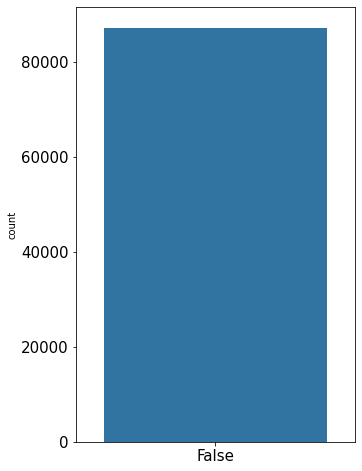

In [ ]:
#Visualizing via Count function 
plt.figure(figsize=(5,8))
sns.countplot(x=df.duplicated())
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)

plt.show()

Now we will drop duplicated rows from data.

In [ ]:
#Droping duplicated rows
df = df.drop_duplicates()

In [ ]:
#Now we will have reduced dataset
df.shape

(87396, 32)

In [ ]:
#Checking for null values
df.isnull().sum().sort_values(ascending=False)[:6].reset_index().rename(columns={'index':'Columns',0:'Null values'})

,Columns,Null values
0,company,82137
1,agent,12193
2,country,452
3,children,4
4,reserved_room_type,0
5,assigned_room_type,0


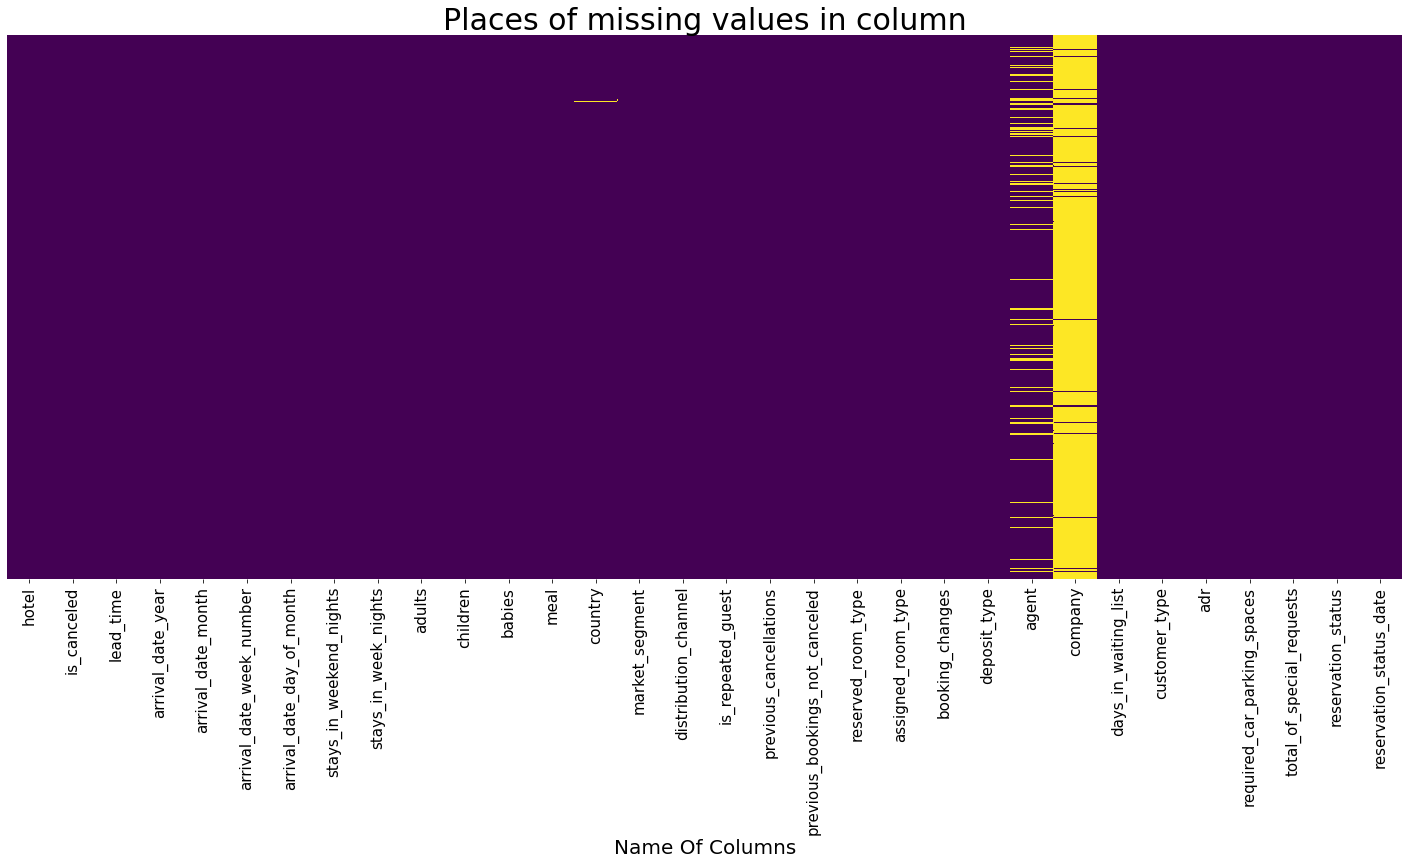

In [ ]:
#Visualizing Null values using heatmap
plt.figure(figsize=(25, 10))
sns.heatmap(hotel_df.isnull(), cbar=False, yticklabels=False,cmap='viridis')
plt.xlabel("Name Of Columns",fontsize=20)
plt.title("Places of missing values in column",fontsize=30)
plt.xticks(fontsize = 15)
plt.show()


**There are null values in four columns namely - children, country, agent,company.**



**For Column,**
1. **children** - As there are only four missing values, so taking it as zero.
2. **country** - Filling missing values  with object 'Others'.
3. **agent** - Filling the missing values with '0'.
4. **company** - Filling the missing values witg '0'.

In [ ]:
#Filling null values with zeros
null_columns = ['children','agent','company']
for i in null_columns:
  df[i].fillna(0,inplace=True)

#For country replacing NA with others
df['country'].fillna('others',inplace=True)

In [ ]:
#Checking null for confirmation
df.isna().sum().sort_values(ascending=False)[:6].reset_index().rename(columns={'index':'Columns',0:'Null values'})

,Columns,Null values
0,hotel,0
1,is_canceled,0
2,reservation_status,0
3,total_of_special_requests,0
4,required_car_parking_spaces,0
5,adr,0


Since from above table we have successfully filled null data

In [ ]:
#Dropping all the row in which addition of the adults, babies and children is zero, i.e. no bookings were made
len(df[df['adults']+df['babies']+df['children']==0])
df.drop(df[df['adults']+df['babies']+df['children']==0].index, inplace=True)

 **Checking categorial values in Categorial columns :**

In [ ]:
cat_columns = list(set(df.drop(columns=['reservation_status_date','country','arrival_date_month']).columns)-set(df.describe()))
for i in cat_columns:
  print(f"Unique values in column {i} is {df[i].unique()} ")

Unique values in column hotel is ['Resort Hotel' 'City Hotel'] 
Unique values in column reserved_room_type is ['C' 'A' 'D' 'E' 'G' 'F' 'H' 'L' 'B'] 
Unique values in column assigned_room_type is ['C' 'A' 'D' 'E' 'G' 'F' 'I' 'B' 'H' 'L' 'K'] 
Unique values in column distribution_channel is ['Direct' 'Corporate' 'TA/TO' 'Undefined' 'GDS'] 
Unique values in column market_segment is ['Direct' 'Corporate' 'Online TA' 'Offline TA/TO' 'Complementary' 'Groups'
 'Undefined' 'Aviation'] 
Unique values in column deposit_type is ['No Deposit' 'Refundable' 'Non Refund'] 
Unique values in column customer_type is ['Transient' 'Contract' 'Transient-Party' 'Group'] 
Unique values in column meal is ['BB' 'FB' 'HB' 'SC' 'Undefined'] 
Unique values in column reservation_status is ['Check-Out' 'Canceled' 'No-Show'] 


Adding new column total_people and total_stay for simplicity

In [ ]:
df['total_people'] = df['adults'] + df['babies'] + df['children']
df['total_stay'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']


In [ ]:
#Checking final count of rows and columns
df.shape


(87230, 34)

# **EDA - Exploratory Data Analysis**
# **(A) - Univariate Analysis**


---





# **(1) Which type of hotel mostly prefered by the guests ?**

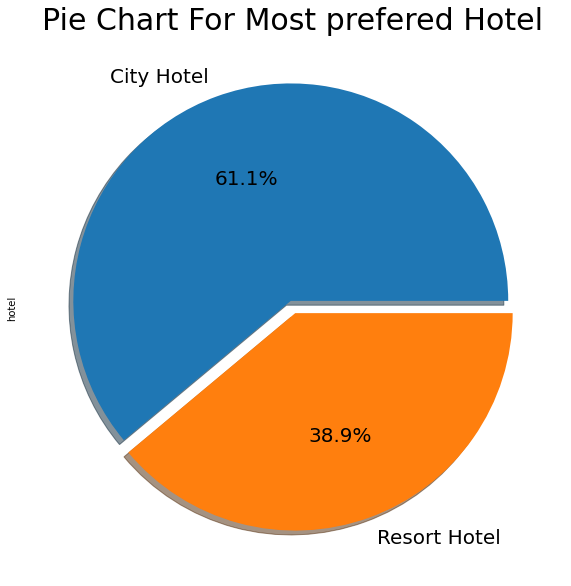

In [ ]:
#Visualizing by Pie chart 
df['hotel'].value_counts().plot.pie(explode=[0.03,0.03], autopct = '%1.1f%%', shadow = True, figsize = (10,10), fontsize = 20)
plt.title('Pie Chart For Most prefered Hotel', fontsize = 30 )
plt.show()

**Observation :** City Hotel is most prefered hotel by guest.

# **(2) Which Agent made most of the boolings**

In [ ]:
#Highest booking made by the Agents
highest_bookings= df.groupby(['agent'])['agent'].agg({'count'}).reset_index().rename(columns={'count': "Most_Bookings" }).sort_values(by='Most_Bookings',ascending=False)

#We had replaced agent with null values by 0, which means it has no bookings, so droping it
highest_bookings.drop(highest_bookings[highest_bookings['agent']==0].index, inplace=True)

#Taking top 10 bookings made by agents
top_ten_bookings_by_agent = highest_bookings[:10]
top_ten_bookings_by_agent

,agent,Most_Bookings
9,9.0,28721
174,240.0,13028
14,14.0,3342
7,7.0,3294
183,250.0,2779
175,241.0,1644
27,28.0,1493
8,8.0,1383
1,1.0,1228
6,6.0,1117


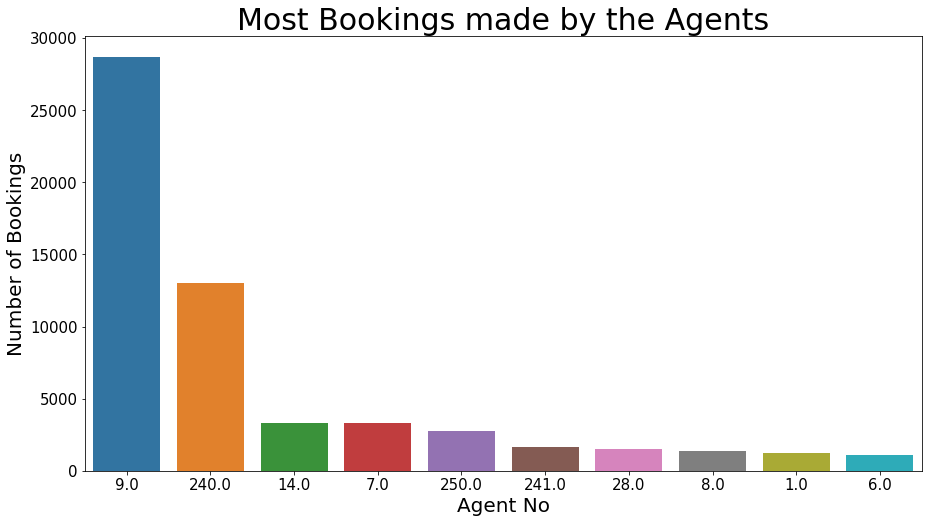

In [ ]:
#Visualizing 
plt.figure(figsize=(15,8))
sns.barplot(x=top_ten_bookings_by_agent['agent'], y=top_ten_bookings_by_agent['Most_Bookings'], order = top_ten_bookings_by_agent['agent'])
plt.xlabel('Agent No', fontsize = 20)
plt.ylabel('Number of Bookings', fontsize = 20)
plt.title('Most Bookings made by the Agents', fontsize = 30)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()


**Observation :** Agent no 9 has made the maximum number of the bookings

# **(3) What is the percentage of cancellation ?**

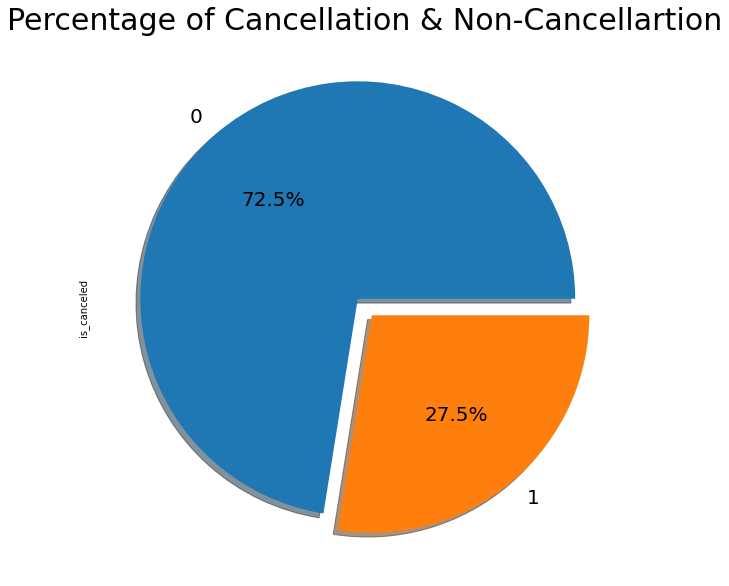

In [ ]:
df['is_canceled'].value_counts().plot.pie(explode = [0.05,0.05], autopct = '%1.1f%%', shadow = True, figsize = (10,10), fontsize = 20)
plt.title('Percentage of Cancellation & Non-Cancellartion', fontsize=30)
plt.show()

**Observation :**
  
  Where, 
  
  0 = Not canceled 

  1 = Canceled

  Therefore, 27.5% of the bookings were canceled.

# **(4) What is the percentage of repeated guest ?**

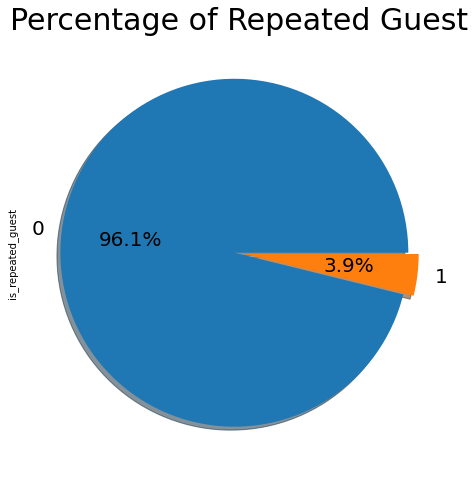

In [ ]:
df['is_repeated_guest'].value_counts().plot.pie(explode = [0.03,0.03], shadow = True, autopct = '%1.1f%%', figsize = [10,8], fontsize = 20)
plt.title('Percentage of Repeated Guest', fontsize = 30)
plt.show()

**Observations :**

There are very less i.e. only 3.9% of repeated guests.

In order to retain the guests, management should take the feedback from guests and improve the services.

# **(5) What is the percentage of the distribution of 'Customer Type' ?**

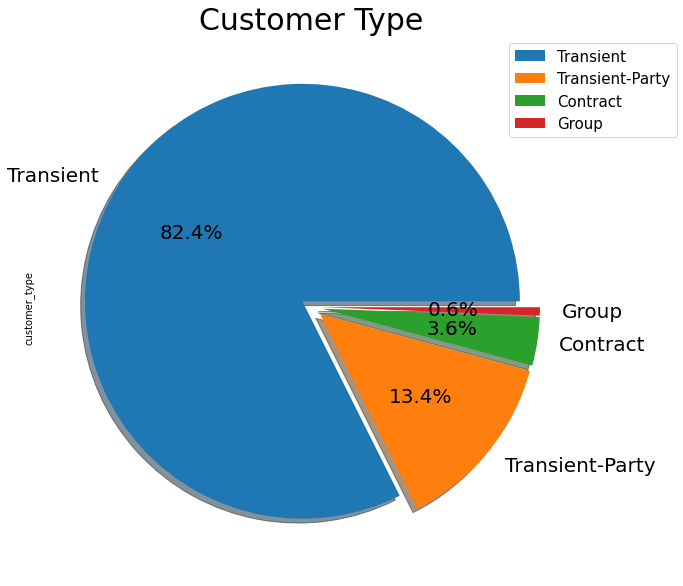

In [ ]:
df['customer_type'].value_counts().plot.pie(explode = [0.05]*4, shadow = True, autopct = '%1.1f%%', figsize = [10,10], fontsize = 20)
plt.title('Customer Type', fontsize = 30)
labels=df['customer_type'].value_counts().index.tolist()
plt.legend(bbox_to_anchor=(0.85, 1), loc='upper left', labels=labels, fontsize=15)
plt.show()

**1. Contract :**

    when the booking has an allotment or other type of contract associated to it

**2. Group :**

    when the booking is associated to a group
**3. Transient :**
    
    when the booking is not part of a group or contract, and is not associated to other transient booking

**4. Transient-Party :**

    when the booking is transient, but is associated to at least other transient booking

**Observations :**

Transient customer type is maximum i.e. 82.4%. Whereas for Group is minimum i.e. 0.6%

# **(6) What is the percentage distribution of 'Required Car Parking spaces' ?**

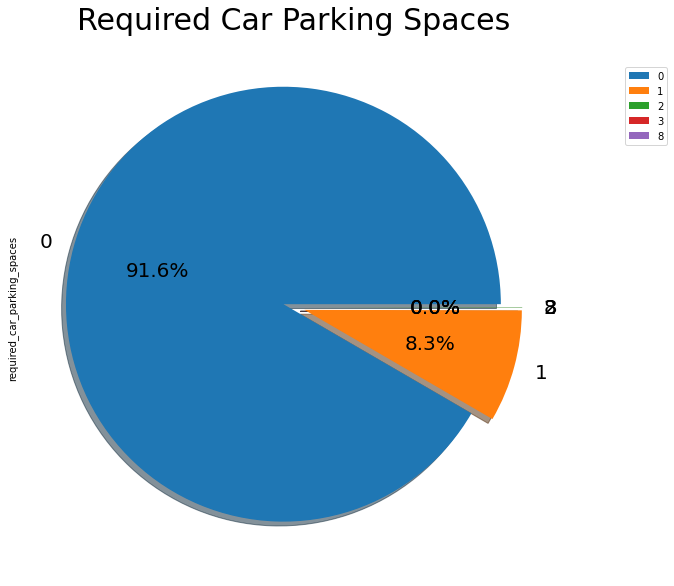

In [ ]:
df['required_car_parking_spaces'].value_counts().plot.pie(explode=[0.05]*5, autopct = '%1.1f%%', shadow = True, figsize= [10,10], fontsize = 20)
plt.title('Required Car Parking Spaces',fontsize = 30)
labels = df['required_car_parking_spaces'].value_counts().index.tolist()
plt.legend(bbox_to_anchor=(1.1,0.95), loc = 'upper left', labels=labels)
plt.show()

**Obsevation :**

Only 8.3% of guest required parking space for one car only, while rest of guests i.e. 91.6% guests dosen't requires any space for parking.

# **(7) What is the percentage of booking changes made by the customer.?**

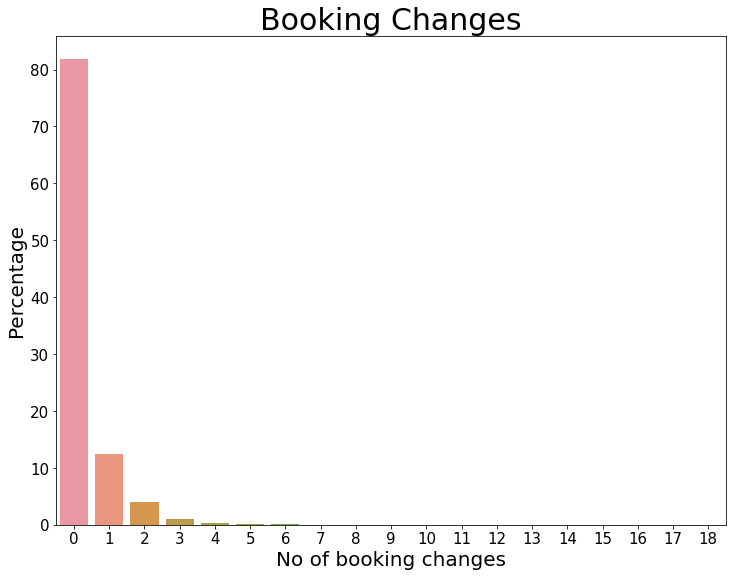

In [ ]:
#df['booking_changes'].value_counts()
book_change = df['booking_changes'].value_counts().reset_index().rename(columns={'index':'numb_of_booking_changes','booking_changes':'Counts'})
plt.figure(figsize=(12,9))
sns.barplot(x=book_change['numb_of_booking_changes'], y=book_change['Counts']*100/df.shape[0])
plt.title('Booking Changes', fontsize=30)
plt.xlabel('No of booking changes', fontsize=20)
plt.ylabel('Percentage', fontsize=20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

Around 80% of booking were not changed by guests.

# **(8) What is percentage distribution of Deposite Type ?**

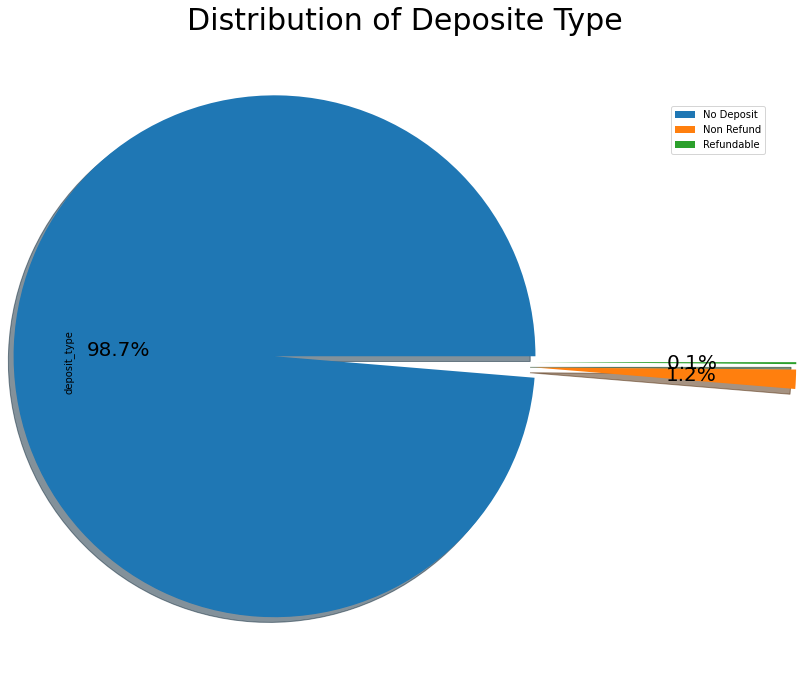

In [ ]:
df['deposit_type'].value_counts().plot.pie(explode = (0.5,0.5,0.5), autopct='%1.1f%%', shadow='True', figsize = (16,12), fontsize= 20, labels = None)
plt.title('Distribution of Deposite Type', fontsize = 30)
labels = df['deposit_type'].value_counts().index.tolist()
plt.legend(bbox_to_anchor = (0.9,0.9), loc = 'upper left', labels = labels)
plt.show()

**Observation :**

98.7% of guests prefers 'No Deposits'.

#**(9) Which type of food mostly preferred by the guests ?**

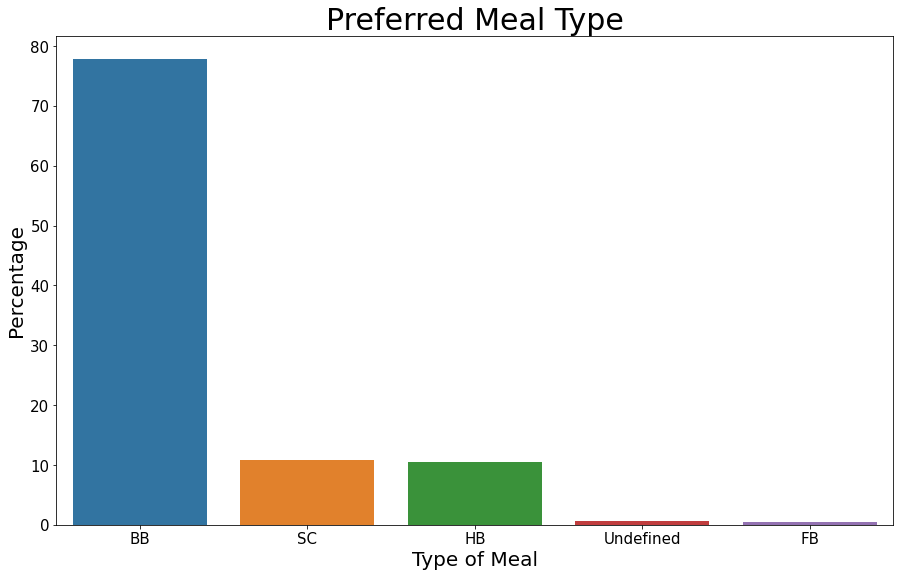

In [ ]:
#df['meal'].value_counts()
meal_dist = df['meal'].value_counts().reset_index().rename(columns={'index':'type_of_meal', 'meal':'counts'})
plt.figure(figsize=(15,9))
sns.barplot(x=meal_dist['type_of_meal'], y=meal_dist['counts']*100/df.shape[0])
plt.title('Preferred Meal Type', fontsize= 30)
plt.xlabel('Type of Meal', fontsize=20)
plt.ylabel('Percentage', fontsize=20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**On X-axis :**

BB - Bed & Breakfast

SC - Self Catering

HB - Half Board

FB - Full Board 



**Observation :**

Most preferred mean by guests is BB i.e. around 78%. Whereas SS and HB are almost equally preferred.



#**(10) From which country most of the guests are coming ?**

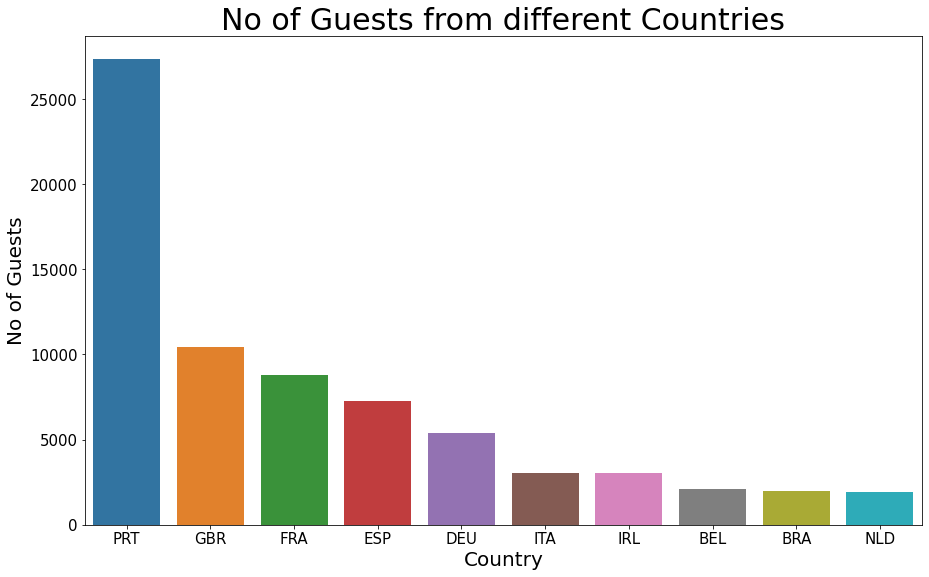

In [ ]:
#df['country'].value_counts()
#Since there are total 178 countries from where guests are coming, therefore for simplicity we will take top ten countries
cont_guests = df['country'].value_counts().reset_index().rename(columns={'index':'countries', 'country':'count'})[:10]

plt.figure(figsize=(15,9))
sns.barplot(x = cont_guests['countries'], y = cont_guests['count'])
plt.title('No of Guests from different Countries', fontsize = 30)
plt.xlabel('Country', fontsize = 20)
plt.ylabel('No of Guests', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observations :**

Most of the guests came from PRT(Portugal) country i.e. more than 25000.

**Abbreevations :**

    1. PRT- Portugal
    2. GBR- United Kingdom
    3. FRA- France
    4. ESP- Spain
    5. DEU - Germany
    6. ITA -Itlay
    7. IRL - Ireland
    8. BEL -Belgium
    9. BRA -Brazil
    10.NLD-Netherlands


#**(11) Which is the most preferred room type by the customers ?**

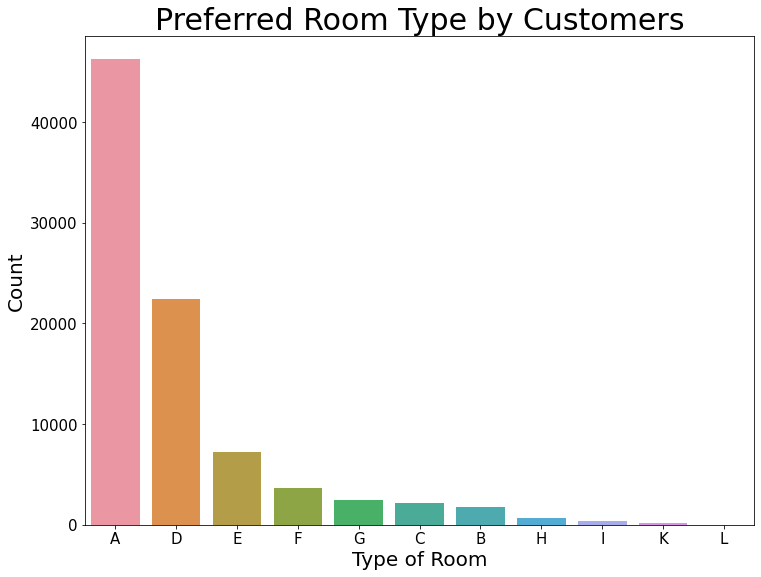

In [ ]:
#df['assigned_room_type'].value_counts()
room_type = df['assigned_room_type'].value_counts().reset_index().rename(columns={'index':'type_of_room', 'assigned_room_type':'Count'})

plt.figure(figsize=(12,9))
sns.barplot(x=room_type['type_of_room'], y=room_type['Count'])
plt.title('Preferred Room Type by Customers', fontsize = 30)
plt.xlabel('Type of Room', fontsize = 20)
plt.ylabel('Count',fontsize=20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :** 

Most preferred room type by guests is of type 'A'.


#**(12) In which month most of the bookings happened?**

In [ ]:
#Grouping by month of arrival and hotel count
book_months_df=df.groupby(['arrival_date_month'])['hotel'].count().reset_index().rename(columns={'hotel':"Counts"})
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
book_months_df['arrival_date_month']=pd.Categorical(book_months_df['arrival_date_month'],categories=months,ordered=True)
book_months_df=book_months_df.sort_values('arrival_date_month')
book_months_df

,arrival_date_month,Counts
4,January,4685
3,February,6083
7,March,7489
0,April,7900
8,May,8344
6,June,7756
5,July,10043
1,August,11242
11,September,6682
10,October,6921


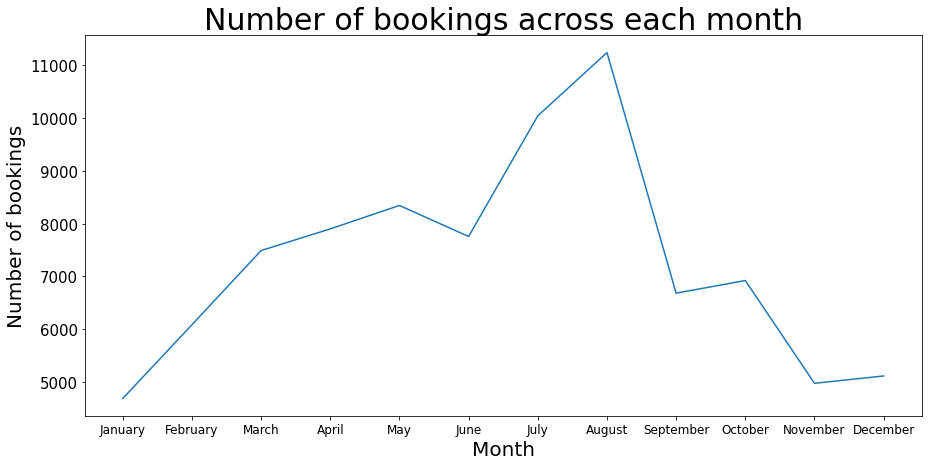

In [ ]:
# set plot size
plt.figure(figsize=(15,7))

#pltting lineplot on x- months & y- booking counts
sns.lineplot(x=book_months_df['arrival_date_month'],y=book_months_df['Counts'])

plt.title('Number of bookings across each month', fontsize = 30)
plt.xlabel('Month', fontsize = 20)
plt.ylabel('Number of bookings', fontsize = 20)
plt.xticks(fontsize = 12)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

In July and August month most of the bookings were made.

#**(13) Which Distribution channel is mostly used for hotel bookings?**

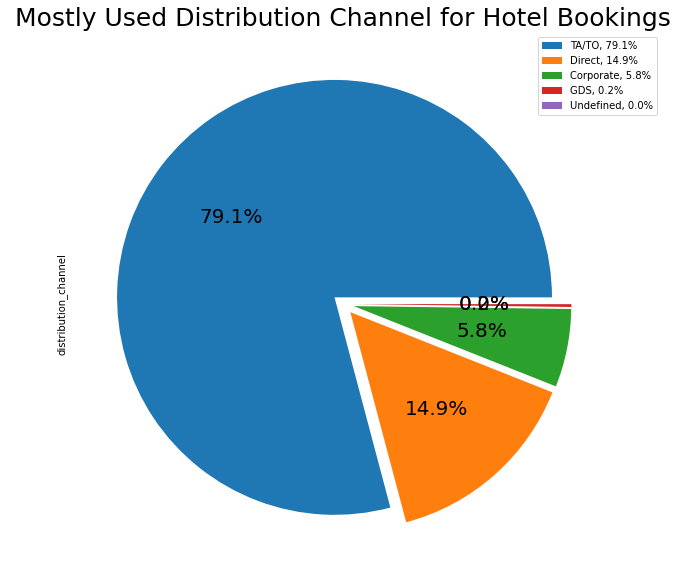

In [ ]:
#df['distribution_channel'].value_counts()
df['distribution_channel'].value_counts().plot.pie(explode = (0.05,0.05,0.05,0.05,0.05), autopct = '%1.1f%%', shadow=False, figsize = (15,10),fontsize=20, labels= None)

df_cha_dist = df['distribution_channel'].value_counts().reset_index().rename(columns={'index':"distribution_channel",'distribution_channel':'count'})
df_cha_dist['percentage'] = round(df_cha_dist['count']*100/df.shape[0],1)

sizes = df_cha_dist['percentage'].values.tolist()

labels = df['distribution_channel'].value_counts().index.tolist()
labels = [f'{l}, {s}%' for l, s in zip(labels, sizes)]
plt.legend(bbox_to_anchor=(0.85, 1), loc='upper left', labels=labels)
plt.title(' Mostly Used Distribution Channel for Hotel Bookings ', fontsize = 25)
plt.show()


**Observation :**


'TA/TO' is mostly(79.1%) used for booking hoetls.

#**(14) Which year had the highest bookings?**

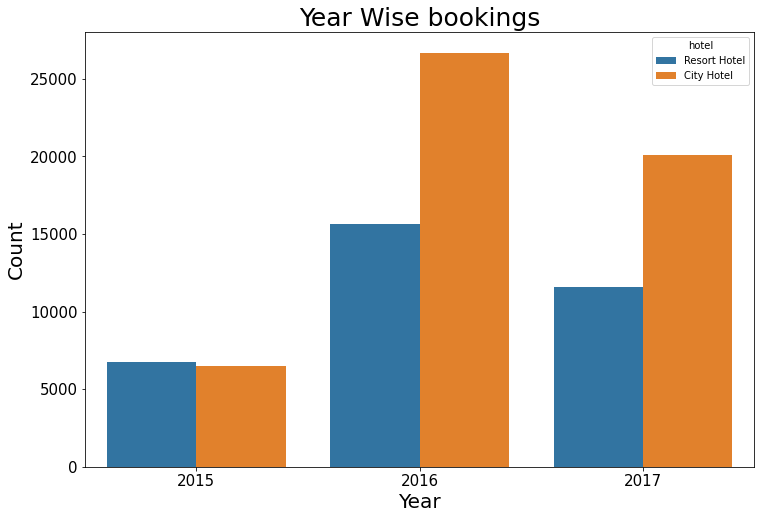

In [ ]:
plt.figure(figsize=(12,8))

#  plot with countplot
sns.countplot(x=df['arrival_date_year'],hue=df['hotel'])
plt.title("Year Wise bookings", fontsize = 25)
plt.xlabel('Year', fontsize = 20)
plt.ylabel('Count', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

2016 had the higest bookings.

2015 had less 7000 bookings.

overall City hotels had the most of the bookings

#**(B) Bivariate and Multivariate Analysis**

In [ ]:
#Group by hotel
group_by_hotel = df.groupby('hotel')

#**(1) Which Hotel type has the highest ADR?**

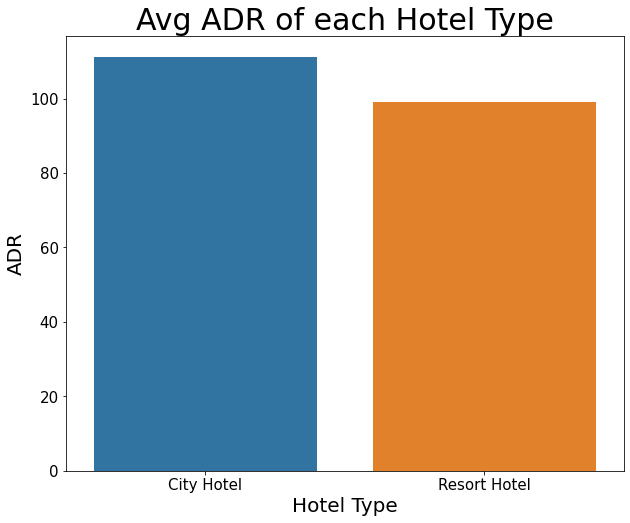

In [ ]:
#grouping by hotel adr
highest_adr = group_by_hotel['adr'].mean().reset_index()

#plotting
plt.figure(figsize=(10,8))
sns.barplot(x=highest_adr['hotel'], y= highest_adr['adr'])
plt.title('Avg ADR of each Hotel Type', fontsize = 30)
plt.xlabel('Hotel Type', fontsize = 20)
plt.ylabel('ADR', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observations :**

City hotel has the highest ADR. That means city hotels are generating more revenues than the resort hotels. More the ADR more is the revenue.

#**(2) Which hotel type has the more lead time?**

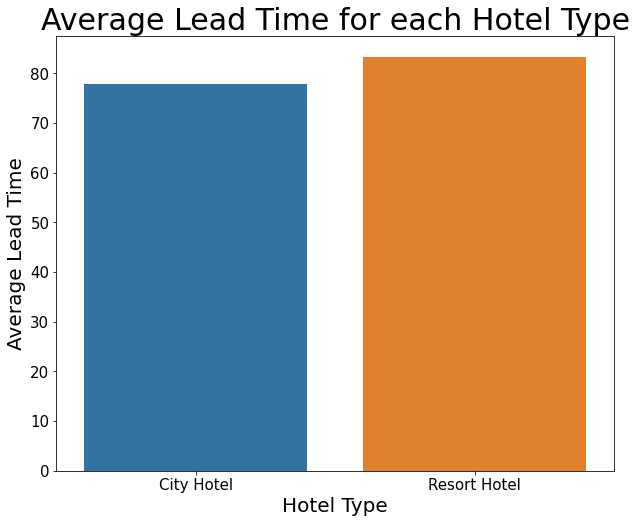

In [ ]:
#Group by hotel and taking mean of the lead time
avg_lead_time=group_by_hotel['lead_time'].mean().reset_index()

#plotting
plt.figure(figsize=(10,8))
sns.barplot(x=avg_lead_time['hotel'], y= avg_lead_time['lead_time'])
plt.title('Average Lead Time for each Hotel Type', fontsize = 30)
plt.xlabel('Hotel Type', fontsize = 20)
plt.ylabel('Average Lead Time', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observations :**

Resort hotels has slightly high avg lead time. That means customers plan their trips very early.

#**(3) Which hotel has highest percentage of booking cancellation?**

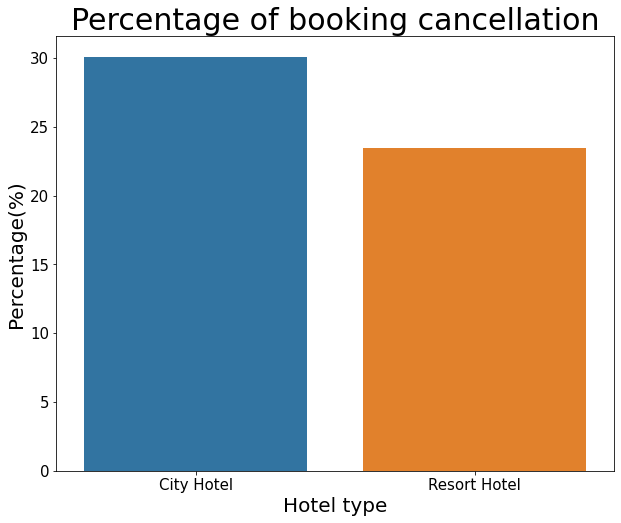

In [ ]:
# booking canceled = 1 
# booking not canceled = 0

# creating new DataFrame where bookings are cancelled
cancelled_df = df[df['is_canceled']==1]

#Grouping by hotel
cancelled_df = cancelled_df.groupby('hotel').size().reset_index().rename(columns = {0:'no_of_cancelled_bookings'})

#Adding total booking columns for percentage calculation 
cancelled_df['total_bookings'] = df.groupby('hotel').size().reset_index().rename(columns={0:'total_bookings'}).drop('hotel', axis=1)
cancelled_df

#plotting the barchat
plt.figure(figsize=(10,8))
sns.barplot(x=cancelled_df['hotel'],y=cancelled_df['no_of_cancelled_bookings']*100/cancelled_df['total_bookings'])

#set labels
plt.xlabel('Hotel type', fontsize = 20)
plt.ylabel('Percentage(%)',fontsize = 20)
plt.title("Percentage of booking cancellation", fontsize = 30)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

City Hotel have more cancelation rate as compared to the Resort Hotel.

#**(4) Which hotel has longer waiting time?**

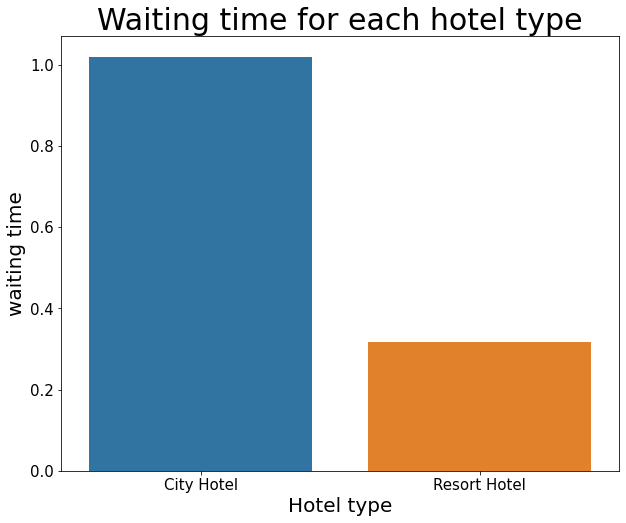

In [ ]:
#groupping by hoetl and taking mean of days in waiting list
waiting_time_df = df.groupby('hotel')['days_in_waiting_list'].mean().reset_index()

#Plot
plt.figure(figsize=(10,8))
sns.barplot(x=waiting_time_df['hotel'],y=waiting_time_df['days_in_waiting_list'])

plt.xlabel('Hotel type',fontsize = 20)
plt.ylabel('waiting time',fontsize = 20)
plt.title("Waiting time for each hotel type",fontsize = 30)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

So the City Hotels has longer waiting period than the Resort Hotels. Thus we can say that City Hotels are much busier than the Resort Hotels.

#**(5) Which Hotels has the most repeated guests?**

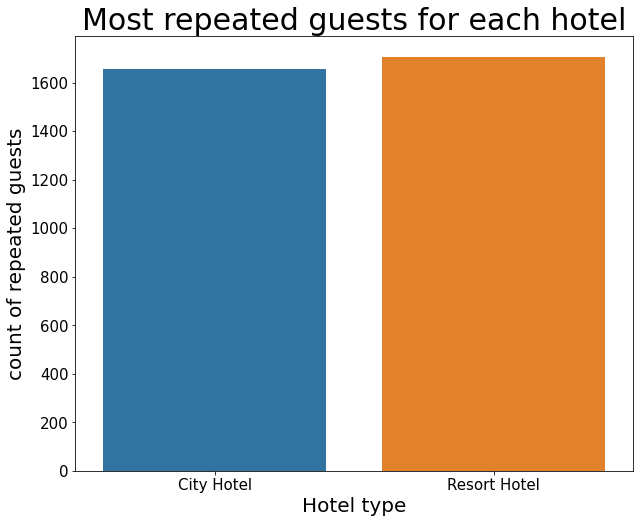

In [ ]:
# repeated guest=1
#not repeated guest=0

#groupby hotel
repeated_guest_df = df[df['is_repeated_guest']==1].groupby('hotel').size().reset_index().rename(columns={0:'numb_of_repeated_guest'})
#repeated_guest_df

#set plot size adn plot barplot
plt.figure(figsize=(10,8))
sns.barplot(x=repeated_guest_df['hotel'],y=repeated_guest_df['numb_of_repeated_guest'])

plt.xlabel('Hotel type',fontsize = 20)
plt.ylabel('count of repeated guests',fontsize = 20)
plt.title("Most repeated guests for each hotel",fontsize = 30)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

Resort Hotel has slightly more repeated guests than the City Hotels. It is almost similar for both hotels.

#**ADR (Avereage Daily Rates) across the different month.**

In [ ]:
#groupby
book_by_month_df = df.groupby(['arrival_date_month','hotel'])['adr'].mean().reset_index()
#book_by_month_df

#month list
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# it will take the order of the month list in the df along with values
book_by_month_df['arrival_date_month'] = pd.Categorical(book_by_month_df['arrival_date_month'], categories=months, ordered = True)

book_by_month_df=book_by_month_df.sort_values('arrival_date_month')
book_by_month_df


,arrival_date_month,hotel,adr
8,January,City Hotel,85.269875
9,January,Resort Hotel,49.181693
6,February,City Hotel,89.266427
7,February,Resort Hotel,54.102809
15,March,Resort Hotel,57.590889
14,March,City Hotel,95.193911
0,April,City Hotel,117.314134
1,April,Resort Hotel,79.283805
17,May,Resort Hotel,80.551101
16,May,City Hotel,128.055724


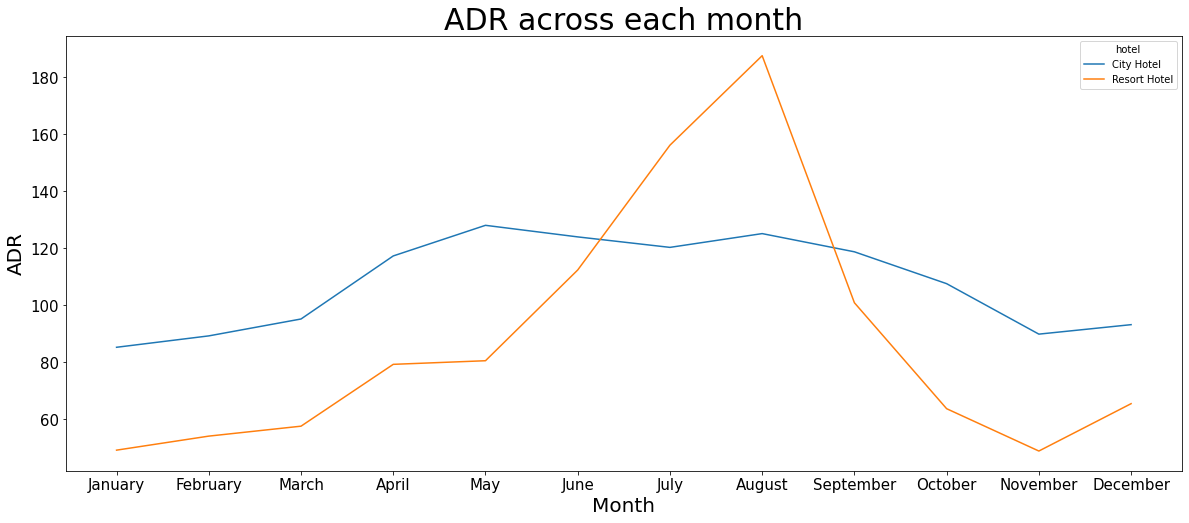

In [ ]:
# set plot size and plot the line
plt.figure(figsize=(20,8))
sns.lineplot(x=book_by_month_df['arrival_date_month'],y=book_by_month_df['adr'],hue=book_by_month_df['hotel'])

# set lables
plt.title('ADR across each month',fontsize=30)
plt.xlabel('Month',fontsize=20)
plt.ylabel('ADR', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()  

**Observation :**

For Resrot hotel is ADR is high in the months June,July,August as compared to City Hotels. May be Customers/People wants to spend their Summer vaccation in Resorts Hotels.

The best time for guests to visit Resort or City hotels is January, February, March, April,October, November and December as the avrage daily rate in this month is very low.

#**(7) Which distribution channel contributed more to ADR in order to increase the the income ?**

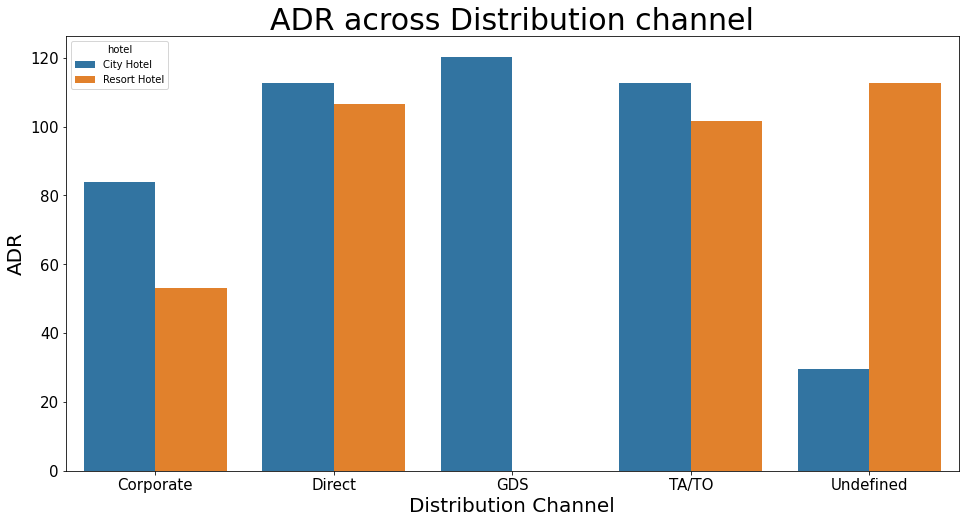

In [ ]:
#Grouping by distribution and hotel
dist_chan_df = df.groupby(['distribution_channel','hotel'])['adr'].mean().reset_index()
#dist_chan_df

plt.figure(figsize=(16,8))
sns.barplot(x='distribution_channel', y='adr', data=dist_chan_df, hue='hotel')
plt.title('ADR across Distribution channel', fontsize = 30)
plt.xlabel('Distribution Channel',fontsize=20)
plt.ylabel('ADR', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show() 

* Corporate- These are corporate hotel booing companies which makes bookings possible.

* GDS-A GDS is a worldwide conduit between travel bookers and suppliers, such as hotels and other accommodation providers. It communicates live product, price and availability data to travel agents and online booking engines, and allows for automated transactions.

* Direct- means that bookings are directly made with the respective hotels

* TA/TO- means that booings are made through travel agents or travel operators.

* Undefined- Bookings are undefined. may be customers made their bookings on arrival.


**Observation :**

From the plot is clear that

'Direct' and 'TA/TO' has almost equally contributed in adr in both type of hotels i.e. 'City Hotel' and 'Resort Hotel'.

GDS has highly contributed in adr in 'City Hotel' type.

GDS needs to increase Resort Hotel bookings.


#**(8) Which distribution channel has the higest cancellation rate?**

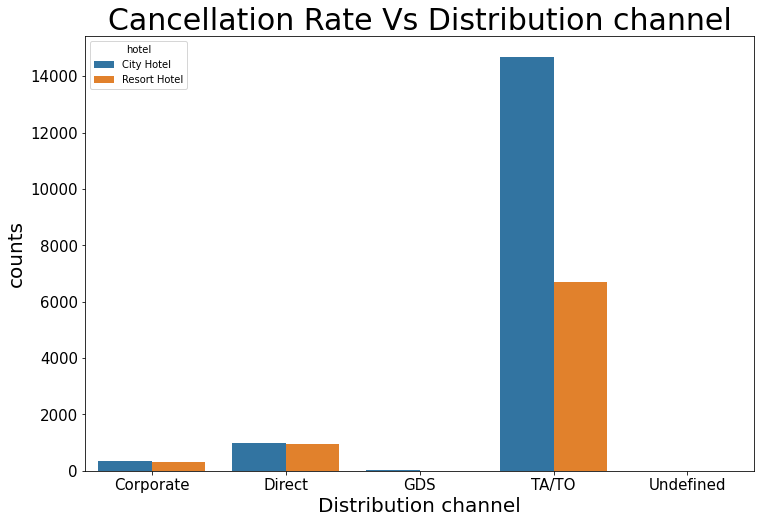

In [ ]:
#canceld = 1
#not canceled = 0
canceled_df=df[df['is_canceled']==1]
canceled_df=canceled_df.groupby(['distribution_channel','hotel']).size().reset_index().rename(columns={0:'Counts'})
#canceled_df

plt.figure(figsize=(12,8))
sns.barplot(x='distribution_channel',y='Counts',hue="hotel",data=canceled_df)
plt.xlabel('Distribution channel', fontsize = 20)
plt.ylabel('counts',fontsize = 20)
plt.title('Cancellation Rate Vs Distribution channel', fontsize = 30)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

* In "TA/TO", City hotels has the high cancellation rate compared to resort hotels.

* In "direct" both the hotels has almost same cancellation rate.

#**(9) Which Market Segment has the higest cancellation rate?**

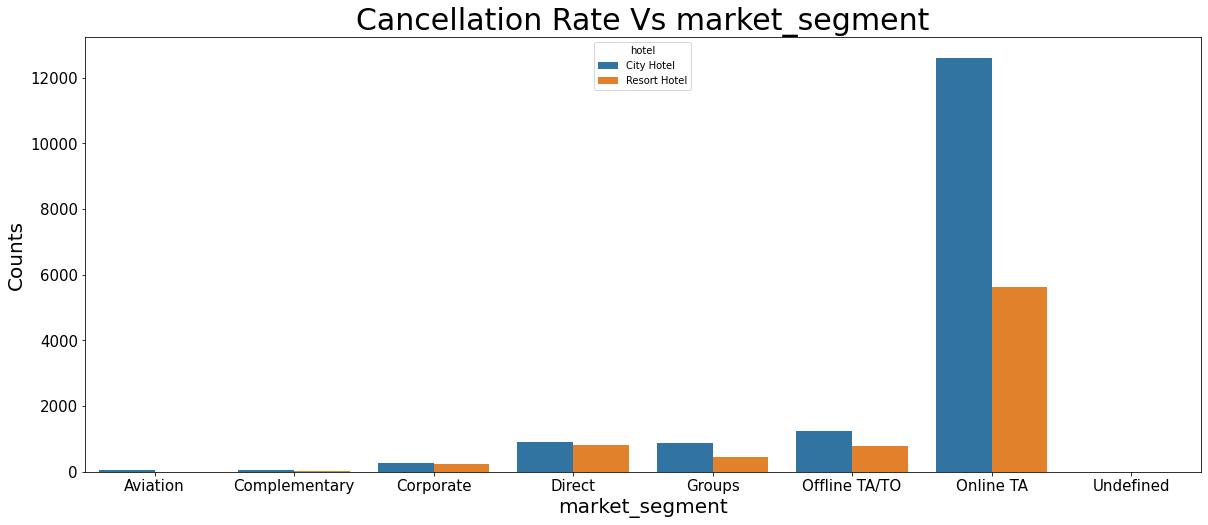

In [ ]:
#canceld = 1
#not canceled = 0
mark_seg_df = df[df['is_canceled']==1]

mark_seg_df = mark_seg_df.groupby(['market_segment','hotel']).size().reset_index().rename(columns={0:'count'})
mark_seg_df

plt.figure(figsize=(20,8))
sns.barplot(x='market_segment',y='count',data= mark_seg_df,hue="hotel")
plt.xlabel('market_segment',fontsize = 20)
plt.ylabel('Counts',fontsize = 20)
plt.title('Cancellation Rate Vs market_segment',fontsize = 30)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

'Online T/A' has the highest cancellation in both type of cities.

In order to reduce the booking cancellations hotels need to set the refundable/ no refundable and deposit policies policies

#**(10) Does the guests alloted with the same room type which was reserved by them?**

In [ ]:
#Defining fun to check alloted room is same as that of reserved by guest

def same_room_allot(x):
  if x['reserved_room_type'] != x['assigned_room_type']:
    return 1
  else:
    return 0
     

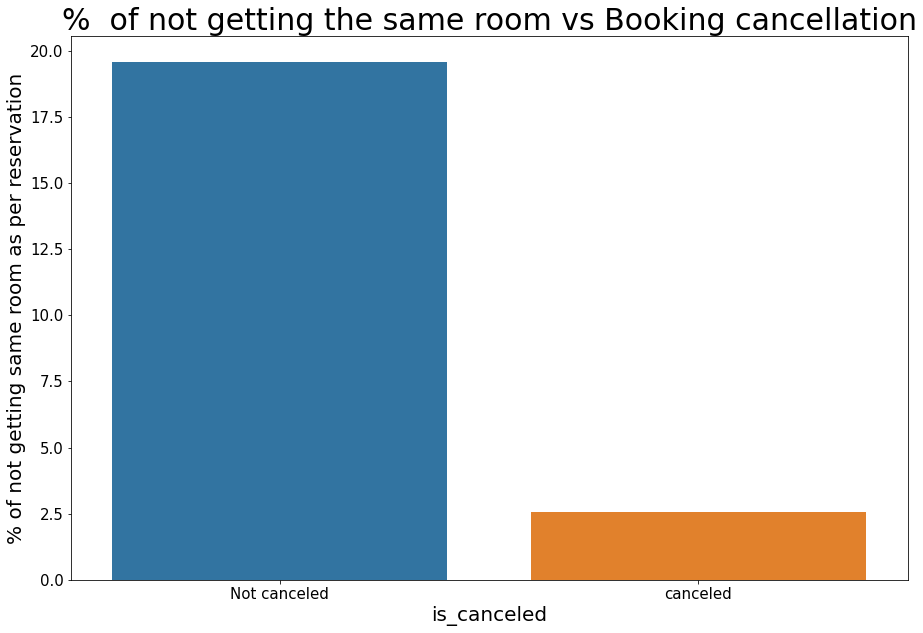

In [ ]:
# create new column to df
df['same_room_alloted_or_not'] = df.apply(lambda x : same_room_allot(x), axis=1)
#df['same_room_alloted_or_not']

#grouping by is canceled
grp_by_canceled_df = df.groupby('is_canceled')

#for percentage wise same room allotment
DF = pd.DataFrame(grp_by_canceled_df['same_room_alloted_or_not'].sum()*100/grp_by_canceled_df.size()).rename(columns={0:'percentage'})
#DF

plt.figure(figsize=(15,10))
sns.barplot(x=DF.index,y=DF['percentage'])
plt.title('%  of not getting the same room vs Booking cancellation', fontsize = 30)
plt.xlabel('is_canceled', fontsize = 20)
plt.ylabel('% of not getting same room as per reservation', fontsize = 20)
plt.xticks([0,1],['Not canceled','canceled'], fontsize = 15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()


**Observation :**

Its is clear that there is no much(2.5%) effect on cancellation of the bookings even if the guests are not assigned with rooms which they reserved during booking.

#**(11) ADR across different market segment**

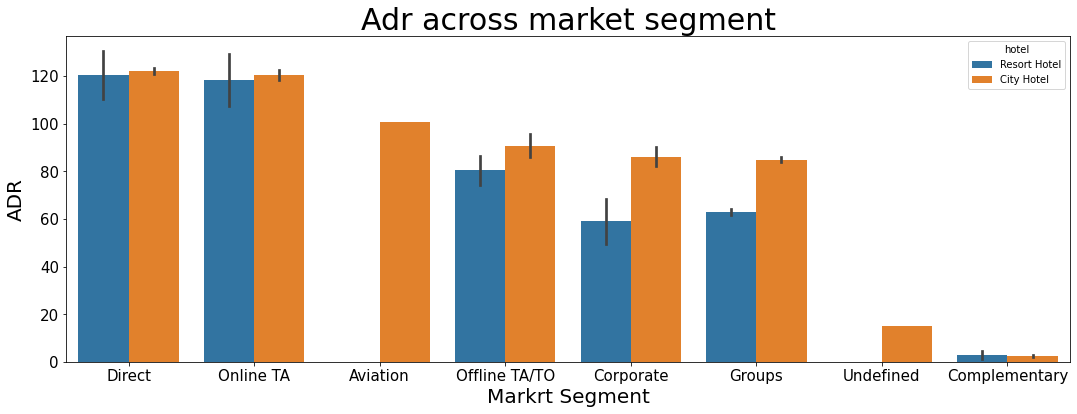

In [ ]:
#Grouping
Grupby=df.groupby(['market_segment','hotel','is_canceled'])['adr'].mean().reset_index()
Grupby

plt.figure(figsize=(18,6))
sns.barplot(x='market_segment',y='adr',hue='hotel',data=Grupby.sort_values(by='adr',ascending=False))
plt.title('Adr across market segment', fontsize=30)
plt.xlabel('Markrt Segment', fontsize = 20)
plt.ylabel('ADR', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()



**Observation :**

'Direct' and 'Online TA' are contributing the most in both types of hotels.

Aviation segment should focus on increasing the bookings of 'City Hotel'

#**(12)What is the Optimal stay length in both types of hotels ?**

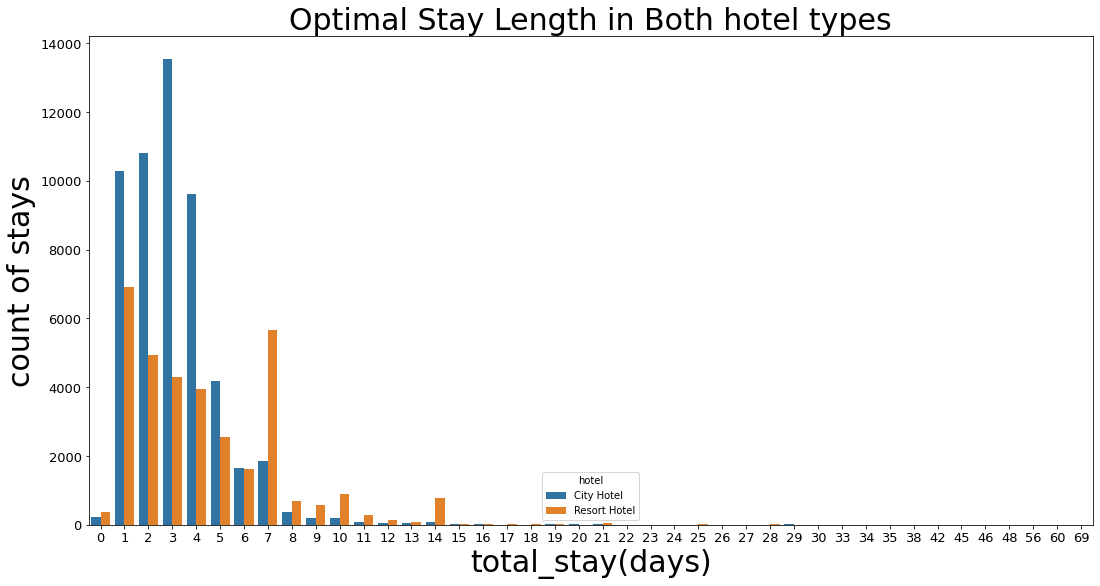

In [ ]:
stay = df.groupby(['total_stay', 'hotel']).agg('count').reset_index()   # group by total stay and hotel
stay = stay.iloc[:, :3]                                                   # take 1st 3 columns
stay = stay.rename(columns={'is_canceled':'Number of stays'})    # rename the columns

plt.figure(figsize=(18,9))
sns.barplot(x='total_stay',y='Number of stays',hue='hotel',data=stay)

plt.title('Optimal Stay Length in Both hotel types', fontsize = 30)
plt.ylabel('count of stays', fontsize = 30)
plt.xlabel('total_stay(days)', fontsize = 30)
plt.xticks(fontsize = 13)
plt.yticks(fontsize = 13)
plt.show()

**Observation :**

Optimal stay in both the type hotel is less than 7 days.

#**(13) Relationship between ADR and total stay.**

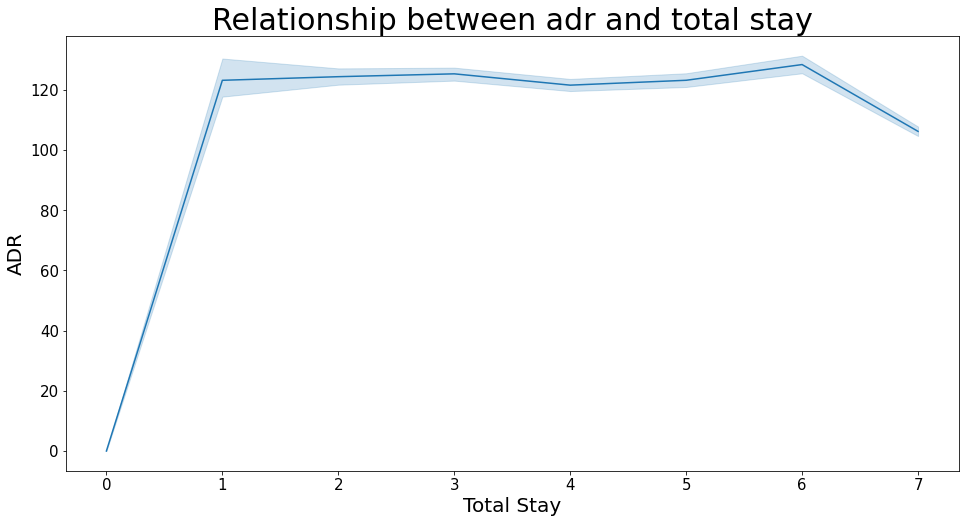

In [ ]:
# Groupby adr,total,stay,hotel,
adr_vs_stay = df.groupby(['total_stay', 'adr','hotel']).agg('count').reset_index()
adr_vs_stay = adr_vs_stay.iloc[:, :3]
adr_vs_stay = adr_vs_stay.rename(columns={'is_canceled':'Number of stays'})
adr_vs_stay=adr_vs_stay[:18000]
adr_vs_stay

#plot line chart
plt.figure(figsize=(16,8))
sns.lineplot(x='total_stay',y='adr',data=adr_vs_stay)
plt.title('Relationship between adr and total stay',fontsize = 30)
plt.xlabel('Total Stay', fontsize = 20)
plt.ylabel('ADR', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

As the total stay increases the adr also increases.


#**Correlation of the columns**

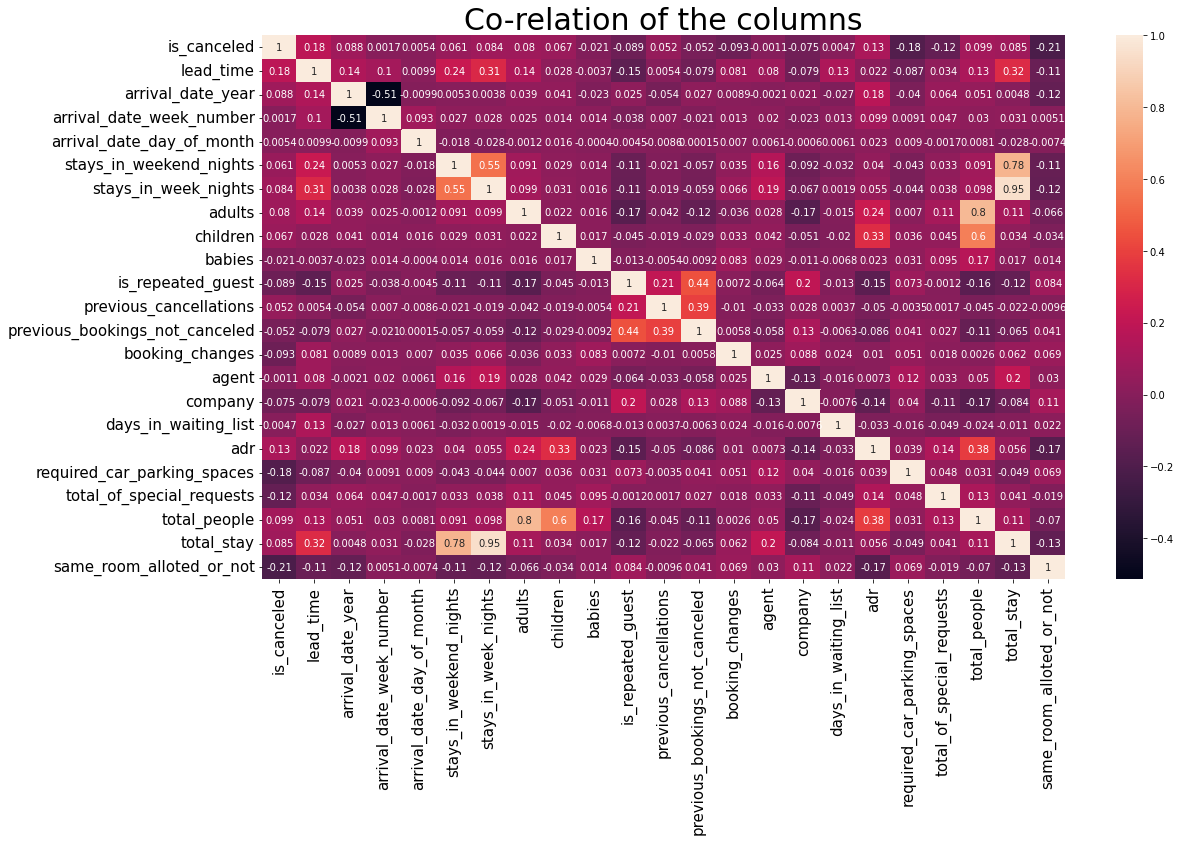

In [ ]:
plt.figure(figsize=(18,10))
sns.heatmap(df.corr(),annot=True)
plt.title('Co-relation of the columns', fontsize = 30)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observations :**

(1) is_canceled and same_room_alloted_or_not are negatively corelated. That means customer is unlikely to cancel his bookings if he don't get the same room as per reserved room. We have visualized it above.

(2) lead_time and total_stay is positively corelated.That means more is the stay of cutsomer more will be the lead time.

(3)adults,childrens and babies are corelated to each other. That means more the people more will be adr.

(4) is_repeated guest and previous bookings not canceled has strong corelation. may be repeated guests are not more likely to cancel their bookings

#**Relationship between the repeated guests and previous bookings not canceled.?**

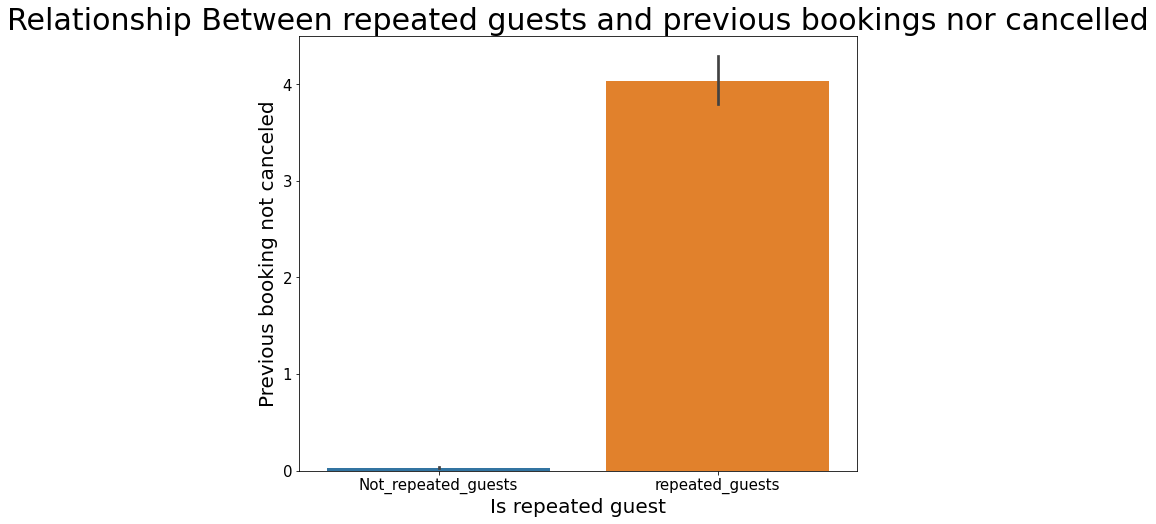

In [ ]:
# repeated guest = 1
# non repeated = 0

repeated_guest_df1 = df[df['is_repeated_guest']==1]
non_repeated_guest_df1 = df[df['is_repeated_guest']==0]

#plottting
plt.figure(figsize=(10,8))
sns.barplot(x=df['is_repeated_guest'],y= df['previous_bookings_not_canceled'])
plt.title('Relationship Between repeated guests and previous bookings nor cancelled', fontsize = 30)
plt.xlabel('Is repeated guest', fontsize = 20)
plt.ylabel('Previous booking not canceled', fontsize = 20)
plt.xticks([0,1],['Not_repeated_guests','repeated_guests'],fontsize=15)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

Not Repeated guests are more likely to cancel their bookings.

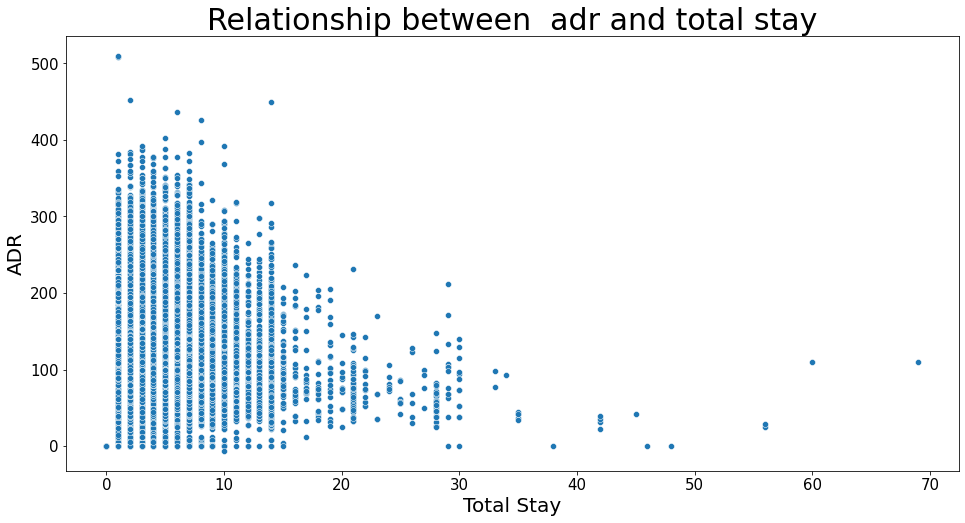

In [ ]:
df.drop(df[df['adr'] > 5000].index, inplace = True)

plt.figure(figsize=(16,8))
sns.scatterplot(x=df['total_stay'],y=df['adr'])
plt.title('Relationship between  adr and total stay', fontsize = 30)
plt.xlabel('Total Stay', fontsize = 20)
plt.ylabel('ADR', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

From above scatter we can say that as the stay increases adr is decreasing. Thus for longer stays customer can get good adr.

#**ADR relationship with total number of people**

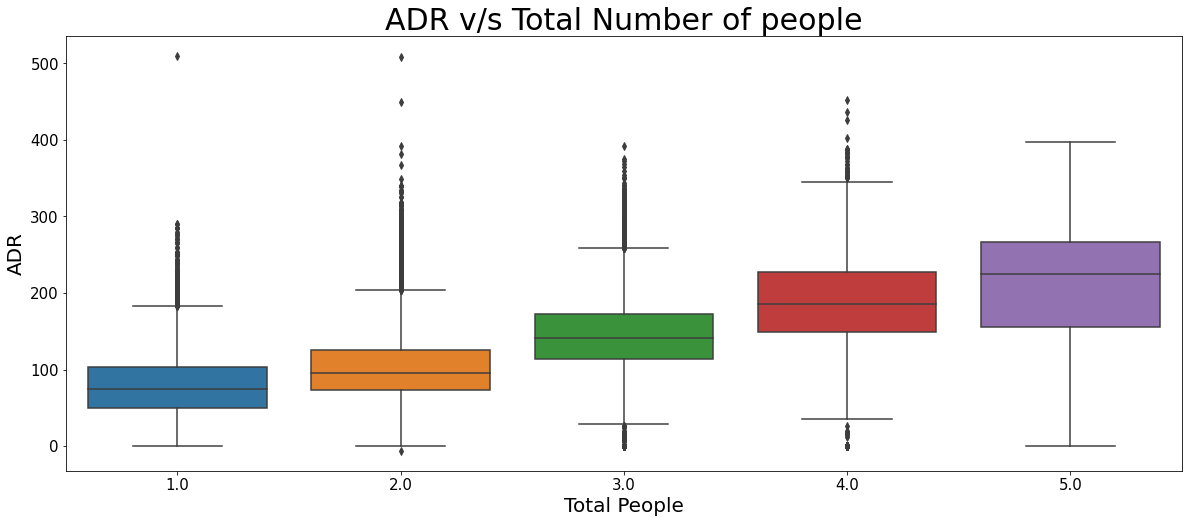

In [ ]:
plt.figure(figsize=(20,8))
dff = df[df['total_people'] < 6]

sns.boxplot(x=dff['total_people'],y=dff['adr'])

# set lables
plt.title('ADR v/s Total Number of people',fontsize = 30)
plt.xlabel('Total People', fontsize = 20)
plt.ylabel('ADR', fontsize = 20)
plt.xticks(fontsize = 15)
plt.yticks(fontsize = 15)
plt.show()

**Observation :**

As the total number of people increases adr also increases.
Thus adr and total people are directly proportional to each other.

#**Conclusions :**



1. City hotels are the most preferred hotel type by the guests. We can say City hotel is the busiest hotel.

2. 27.5 % bookings were got cancelled out of all the bookings.

3. Only 3.9 % people were revisited the hotels. Rest 96.1 % were new guests. Thus retention rate is low.

4. The percentage of 0 changes made in the booking was more than 82 %. Percentage of Single changes made was about 10%.

5. Most of the customers (91.6%) do not require car parking spaces.

6. 79.1 % bookings were made through TA/TO (travel agents/Tour operators).

7. BB( Bed & Breakfast) is the most preferred type of meal by the guests.

8. Maximum number of guests were from Portugal, i.e. more than 25000 guests.

9. Most of the bookings for City hotels and Resort hotel were happened in 2016.

10. Average ADR for city hotel is high as compared to resort hotels. These City hotels are generating more revenue than the resort hotels.

11. Booking cancellation rate is high for City hotels which almost 30 %.

12. Average lead time for resort hotel is high.

13. Waiting time period for City hotel is high as compared to resort hotels. That means city hotels are much busier than Resort hotels.

14. Resort hotels have the most repeated guests.

15. Optimal stay in both the type hotel is less than 7 days. Usually people stay for a week.

16. Almost 19 % people did not cancel their bookings even after not getting the same room which they reserved while booking hotel. Only 2.5 % people cancelled the booking.